In [2]:
library(DBI)
library(RPostgres)
library(tidyverse)
library(glue)
library(httr)
library(jsonlite)
library(dplyr)
library(tidyr)
library(lubridate)
library(stringr)
library(ggplot2)
library(readr)

source("pitcher_profile_functions.r")
source("data_extract_functions.r")


pitcher_id <- 669373
pitcher_scouting_report_df <- pull_pitcher_scouting_report_from_database(pitcher_id)

# grab specific pitch type >= 10% usage

pitcher_pitch_arsenal <- create_pitcher_pitch_arsenal(pitcher_scouting_report_df)

pitcher_statcast_df <- pull_pitcher_statcast_data_from_csv(pitcher_id, pitcher_pitch_arsenal)

pitcher_pitch_usage_df <- create_pitcher_pitch_usage_df(pitcher_statcast_df)

pitcher_pitch_characteristics_df <- create_pitcher_pitch_characteristics_df(pitcher_statcast_df)

pitcher_pitch_performance_df <- create_pitcher_pitch_performance_df(pitcher_statcast_df)

########### plots #####################

pitch_visual_plots <- create_pitcher_pitch_visual_plots(pitcher_statcast_df)

pitch_usage_plots <- create_pitcher_usage_plots(pitcher_pitch_usage_df)

#pitch_characteristics_plots <- create_pitch_characteristics_plots(pitcher_pitch_characteristics_df)

pitch_tendencies_plots <- create_pitch_tendency_plots(pitcher_scouting_report_df)

New names:
• `` -> `...1`


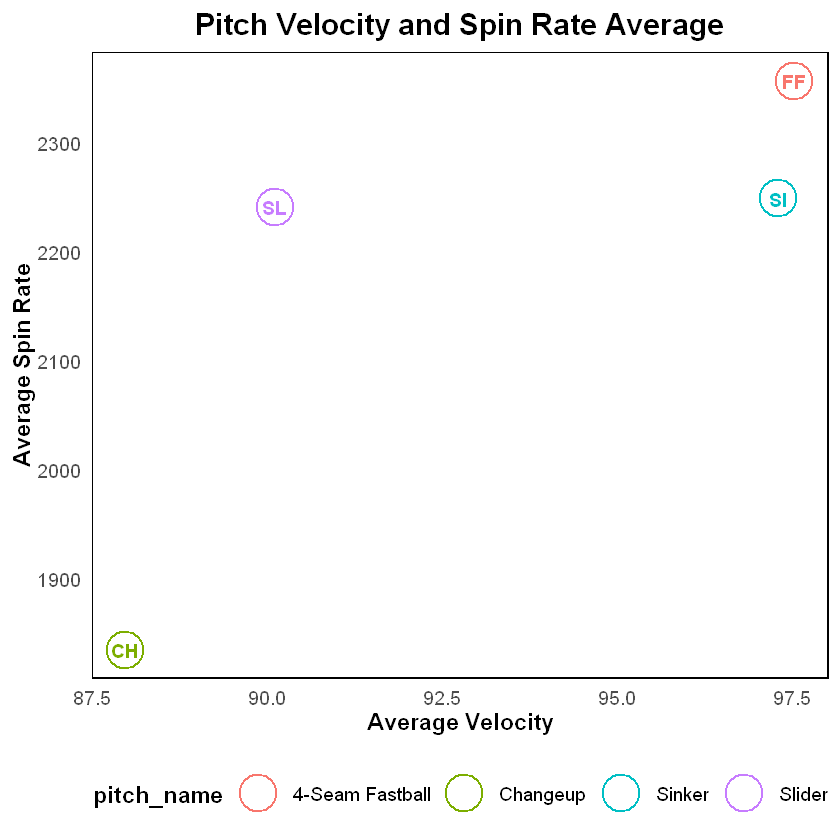

In [111]:
#source("pitcher_profile_functions.r")
#source("data_extract_functions.r")

ggplot(pitcher_pitch_characteristics_df,
        aes(x = avg_velo, y = avg_spin, color = pitch_name)) +
        geom_point(size = 10, shape = 21, fill = "white", stroke = 1.2) +
        geom_text(aes(label = pitch_type),
            size = 4,
            fontface = "bold",
            show.legend = FALSE) + 
        labs(
        title = "Pitch Velocity and Spin Rate Average",
        x = "Average Velocity",
        y = "Average Spin Rate",
        color = "Pitch Name"
        ) +
        theme_minimal(base_size = 14) +
        theme(
            plot.title = element_text(face = "bold", size = 18, hjust = 0.5),
            axis.title = element_text(face = "bold"),
            panel.grid = element_blank(),
            legend.position = "bottom",
            legend.title = element_text(face = "bold"),
            panel.border = element_rect(color = "black", fill = NA)
        )







In [5]:
pitcher_pitch_characteristics_df

pitch_type,pitch_name,avg_velo,avg_rel_x,avg_rel_y,avg_rel_z,avg_hmov,avg_vmov,avg_vx0,avg_vy0,avg_vz0,avg_ax,avg_ay,avg_az,avg_spin
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CH,Changeup,87.97,1.90,54.09,6.07,1.24,0.52,-6.21,-127.87,-5.36,14.86,26.97,-25.50,1834.755
FF,4-Seam Fastball,97.54,1.59,54.05,6.23,0.29,1.43,-4.98,-141.83,-6.69,5.05,32.91,-11.58,2356.345
SI,Sinker,97.30,1.69,54.01,6.13,1.10,1.12,-7.60,-141.39,-6.44,16.45,32.38,-15.84,2248.622
SL,Slider,90.11,1.95,54.03,6.07,-0.27,0.39,-4.53,-131.18,-4.49,-2.22,26.05,-26.93,2240.862
